In [1]:
import scanpy as sc
import omicverse as ov
ov.plot_set()

2024-11-24 21:11:20.504117: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-11-24 21:11:20.518555: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-11-24 21:11:20.522786: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-11-24 21:11:21.252280: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT



   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

Version: 1.6.9, Tutorials: https://omicverse.readthedocs.io/
Dependency error: (pydeseq2 0.4.11 (/mnt/home/zehuazeng/software/rsc/lib/python3.10/site-packages), Requirement.parse('pydeseq2<=0.4.0,>=0.3'))


## Anno raw data

In [3]:
adata=sc.read('data/GC_RNA/GC_ANNO.h5ad',compression='gzip')
adata

AnnData object with n_obs × n_vars = 148350 × 3000
    obs: 'patient', 'CancerType', 'CancerStage', 'nUMIs', 'mito_perc', 'detected_genes', 'cell_complexity', 'n_genes', 'doublet_score', 'predicted_doublet', 'passing_mt', 'passing_nUMIs', 'passing_ngenes', '_scvi_batch', '_scvi_labels', 'leiden', 'celltype_gbi', 'celltype_gpt', 'best_clusters', 'gpt_celltype_0', 'gpt_celltype_1', 'gpt_celltype_2', 'gpt_celltype_3', 'gpt_celltype_4', 'best_celltype', 'Major_celltype', 'Minor_celltype', 'C_scANVI', 'cell_type_from_scMulan', 'cell_type_from_mulan_smoothing', 'smoothing_score', 'cell_abbreviations', 'log2umi', 'log2counts', 'pct_counts_mt'
    var: 'mt', 'n_cells', 'percent_cells', 'robust', 'means', 'variances', 'residual_variances', 'highly_variable_rank', 'highly_variable_nbatches', 'highly_variable_intersection', 'highly_variable_features'
    uns: 'CancerStage_colors', 'CancerType_colors', 'Smoothing', 'bench_best_res', 'best_celltype_colors', 'cell_type_from_mulan_smoothing_colors', 

In [33]:
adata_gas=sc.read('data/GC_RNA/gas_raw.h5ad',compression='gzip')
adata_gas.obs

,sample_batch,initial_size_unspliced,initial_size_spliced,initial_size,srr_name
SRR9713141:AAACCTGCAAGT,CATC-1,192,221,221.0,SRR9713141
SRR9713141:AAACCTGCAGGA,TTGG-1,1025,4841,4841.0,SRR9713141
SRR9713141:AAACCTGGTCTA,AACC-1,217,182,182.0,SRR9713141
SRR9713141:AAACCTGGTGAG,TGAC-1,300,457,457.0,SRR9713141
SRR9713141:AAACCTGTCCTC,TAGC-1,575,1444,1444.0,SRR9713141
...,...,...,...,...,...
SRR9713146:TTTGTCACATGG,TAGG-1,152,431,431.0,SRR9713146
SRR9713146:TTTGTCAGTACC,GGCT-1,1654,798,798.0,SRR9713146
SRR9713146:TTTGTCAGTCAC,CTAA-1,1688,8685,8685.0,SRR9713146
SRR9713146:TTTGTCAGTCTC,TCGT-1,266,182,182.0,SRR9713146


In [34]:
gas_meta=ov.read('data/GC_RNA/SraRunTable.csv',index_col=0)
gas_meta.head()

,AGE,agent,Assay Type,AvgSpotLen,Bases,BioProject,BioSample,Bytes,Center Name,Consent,...,pathological_lesions,Platform,ReleaseDate,create_date,version,Sample Name,sex,source_name,SRA Study,subject_id
Run,,,,,,,,,,,,,,,,,,,,,
SRR9713116,58,None,RNA-Seq,300,28485140400,PRJNA555477,SAMN12320058,14559388384,GEO,public,...,Normal,ILLUMINA,2019-07-22T00:00:00Z,2019-07-19T08:47:00Z,1,GSM3954946,male,stomach,SRP215370,P1
SRR9713117,58,None,RNA-Seq,300,27638507400,PRJNA555477,SAMN12320058,14040389755,GEO,public,...,Normal,ILLUMINA,2019-07-22T00:00:00Z,2019-07-19T08:47:00Z,1,GSM3954946,male,stomach,SRP215370,P1
SRR9713120,62,None,RNA-Seq,300,31348280700,PRJNA555477,SAMN12320056,15221547903,GEO,public,...,Normal,ILLUMINA,2019-07-22T00:00:00Z,2019-07-19T09:10:00Z,1,GSM3954948,male,stomach,SRP215370,P9
SRR9713123,51,None,RNA-Seq,300,28306822800,PRJNA555477,SAMN12320055,13927061864,GEO,public,...,Chronic atrophic gastritis,ILLUMINA,2019-07-22T00:00:00Z,2019-07-19T08:34:00Z,1,GSM3954949,male,stomach,SRP215370,P3
SRR9713124,51,None,RNA-Seq,300,28000754400,PRJNA555477,SAMN12320055,13783473545,GEO,public,...,Chronic atrophic gastritis,ILLUMINA,2019-07-22T00:00:00Z,2019-07-19T08:37:00Z,1,GSM3954949,male,stomach,SRP215370,P3


In [35]:
gas_srr_gsm_dict=dict(zip(
    gas_meta.index.tolist(),
    gas_meta['Sample Name'].tolist()
))

In [36]:
adata_gas.obs['gsm']=adata_gas.obs['srr_name'].map(gas_srr_gsm_dict)
adata_gas.obs.head()

,sample_batch,initial_size_unspliced,initial_size_spliced,initial_size,srr_name,gsm
SRR9713141:AAACCTGCAAGT,CATC-1,192,221,221.0,SRR9713141,GSM3954953
SRR9713141:AAACCTGCAGGA,TTGG-1,1025,4841,4841.0,SRR9713141,GSM3954953
SRR9713141:AAACCTGGTCTA,AACC-1,217,182,182.0,SRR9713141,GSM3954953
SRR9713141:AAACCTGGTGAG,TGAC-1,300,457,457.0,SRR9713141,GSM3954953
SRR9713141:AAACCTGTCCTC,TAGC-1,575,1444,1444.0,SRR9713141,GSM3954953


In [37]:
data = """
GSM3954946	Non-atrophic gastritis 1
GSM3954947	Non-atrophic gastritis 2
GSM3954948	Non-atrophic gastritis 3
GSM3954949	Chronic atrophic gastritis 1
GSM3954950	Chronic atrophic gastritis 2
GSM3954951	Chronic atrophic gastritis 3
GSM3954952	Wild Intestinal metaplasia 1
GSM3954953	Wild Intestinal metaplasia 2
GSM3954954	Severe Intestinal metaplasia 1
GSM3954955	Severe Intestinal metaplasia 2
GSM3954956	Severe Intestinal metaplasia 3
GSM3954957	Severe Intestinal metaplasia 4
GSM3954958	Early gastric cancer
"""

data = """
GSM3954946	NAG1
GSM3954947	NAG2
GSM3954948	NAG3
GSM3954949	CAG1
GSM3954950	CAG2
GSM3954951	CAG3
GSM3954952	IMW1
GSM3954953	IMW2
GSM3954954	IMS1
GSM3954955	IMS2
GSM3954956	IMS3
GSM3954957	IMS4
GSM3954958	EGC
"""

# Split the data into lines
lines = data.strip().split('\n')

# Create a dictionary from the lines
result_dict = {}
for line in lines:
    key, value = line.split('\t', 1)
    result_dict[key] = value
result_dict

{'GSM3954946': 'NAG1',
 'GSM3954947': 'NAG2',
 'GSM3954948': 'NAG3',
 'GSM3954949': 'CAG1',
 'GSM3954950': 'CAG2',
 'GSM3954951': 'CAG3',
 'GSM3954952': 'IMW1',
 'GSM3954953': 'IMW2',
 'GSM3954954': 'IMS1',
 'GSM3954955': 'IMS2',
 'GSM3954956': 'IMS3',
 'GSM3954957': 'IMS4',
 'GSM3954958': 'EGC'}

In [38]:
adata_gas.obs['patient']=adata_gas.obs['gsm'].map(result_dict)
adata_gas.obs.head()

,sample_batch,initial_size_unspliced,initial_size_spliced,initial_size,srr_name,gsm,patient
SRR9713141:AAACCTGCAAGT,CATC-1,192,221,221.0,SRR9713141,GSM3954953,IMW2
SRR9713141:AAACCTGCAGGA,TTGG-1,1025,4841,4841.0,SRR9713141,GSM3954953,IMW2
SRR9713141:AAACCTGGTCTA,AACC-1,217,182,182.0,SRR9713141,GSM3954953,IMW2
SRR9713141:AAACCTGGTGAG,TGAC-1,300,457,457.0,SRR9713141,GSM3954953,IMW2
SRR9713141:AAACCTGTCCTC,TAGC-1,575,1444,1444.0,SRR9713141,GSM3954953,IMW2


In [39]:
adata_gas.obs.index=[f"{k}:{i.split(':')[1]}{j}" for i,j,k in zip(adata_gas.obs.index.tolist(),
                                        adata_gas.obs['sample_batch'].tolist(),
                                       adata_gas.obs['patient'].tolist())]

In [49]:
adata_gas.obs['patient'].unique()

['IMW2', 'IMS4', 'IMS2', 'EGC', 'IMS3', 'IMW1', 'IMS1']
Categories (7, object): ['IMW1', 'IMW2', 'IMS1', 'IMS2', 'IMS3', 'IMS4', 'EGC']

In [40]:
adata_gas.obs.head()

,sample_batch,initial_size_unspliced,initial_size_spliced,initial_size,srr_name,gsm,patient
IMW2:AAACCTGCAAGTCATC-1,CATC-1,192,221,221.0,SRR9713141,GSM3954953,IMW2
IMW2:AAACCTGCAGGATTGG-1,TTGG-1,1025,4841,4841.0,SRR9713141,GSM3954953,IMW2
IMW2:AAACCTGGTCTAAACC-1,AACC-1,217,182,182.0,SRR9713141,GSM3954953,IMW2
IMW2:AAACCTGGTGAGTGAC-1,TGAC-1,300,457,457.0,SRR9713141,GSM3954953,IMW2
IMW2:AAACCTGTCCTCTAGC-1,TAGC-1,575,1444,1444.0,SRR9713141,GSM3954953,IMW2


In [55]:
ax_dict={}
for p in adata_gas.obs['patient'].unique():
    print(p,adata.obs.loc[adata.obs['patient']==p].index[0])
    ax_dict[p]=adata.obs.loc[adata.obs['patient']==p].index[0].split('-')[1]

IMW2 IMW2:AAACCTGCAAACAACA-8
IMS4 IMS4:AAACCTGCATGCCTAA-13
IMS2 IMS2:AAACCTGGTCTAGTGT-11
EGC EGC:AAACCTGAGAAACGAG-14
IMS3 IMS3:AAACCTGCAACGCACC-12
IMW1 IMW1:AAACCTGAGCGTTGCC-7
IMS1 IMS1:AAACCTGCAATGCCAT-10


In [60]:
from tqdm import tqdm
new_index=[]
for i in tqdm(adata_gas.obs.index):
    name=i.split(':')[0]
    if name in adata_gas.obs['patient'].unique():
        term=i
        term=term.replace(f'-1',f'-{ax_dict[name]}')
        new_index.append(term)
    else:
        new_index.append(i)

100%|██████████| 23776/23776 [00:02<00:00, 8573.45it/s]


In [63]:
adata_gas.obs.index=new_index

In [64]:
both_idx=list(set(adata.obs.index.tolist()) & set(adata_gas.obs.index.tolist()))
len(both_idx)

14809

In [65]:
adata_gas=adata_gas[both_idx]
adata=adata[both_idx]

In [66]:
for i in list(set(adata.obs.columns) - set(adata_gas.obs.columns)):
    adata_gas.obs[i]=adata.obs[i].tolist()
adata_gas.obsm=adata.obsm.copy()
adata_gas.obsp=adata.obsp.copy()
adata_gas.uns=adata.uns.copy()

In [67]:
adata_gas

AnnData object with n_obs × n_vars = 14809 × 38606
    obs: 'sample_batch', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'srr_name', 'gsm', 'patient', 'CancerType', 'mito_perc', 'cell_type_from_mulan_smoothing', 'CancerStage', 'gpt_celltype_0', 'Minor_celltype', 'cell_type_from_scMulan', 'log2umi', 'passing_ngenes', 'passing_mt', 'C_scANVI', 'gpt_celltype_2', 'best_celltype', 'cell_complexity', 'leiden', 'passing_nUMIs', 'cell_abbreviations', 'pct_counts_mt', 'detected_genes', 'smoothing_score', 'gpt_celltype_4', 'best_clusters', '_scvi_labels', 'celltype_gbi', 'n_genes', 'log2counts', 'doublet_score', 'gpt_celltype_1', 'celltype_gpt', 'Major_celltype', '_scvi_batch', 'nUMIs', 'gpt_celltype_3', 'predicted_doublet'
    var: 'gene_ids', 'feature_types', 'genome', 'Accession', 'Chromosome', 'End', 'Start', 'Strand'
    uns: 'CancerStage_colors', 'CancerType_colors', 'Smoothing', 'bench_best_res', 'best_celltype_colors', 'cell_type_from_mulan_smoothing_colors', 'cell_t

[<AxesSubplot: title={'center': 'best_celltype'}, xlabel='X_mde_scVI1', ylabel='X_mde_scVI2'>,
 <AxesSubplot: title={'center': 'CD3E'}, xlabel='X_mde_scVI1', ylabel='X_mde_scVI2'>]

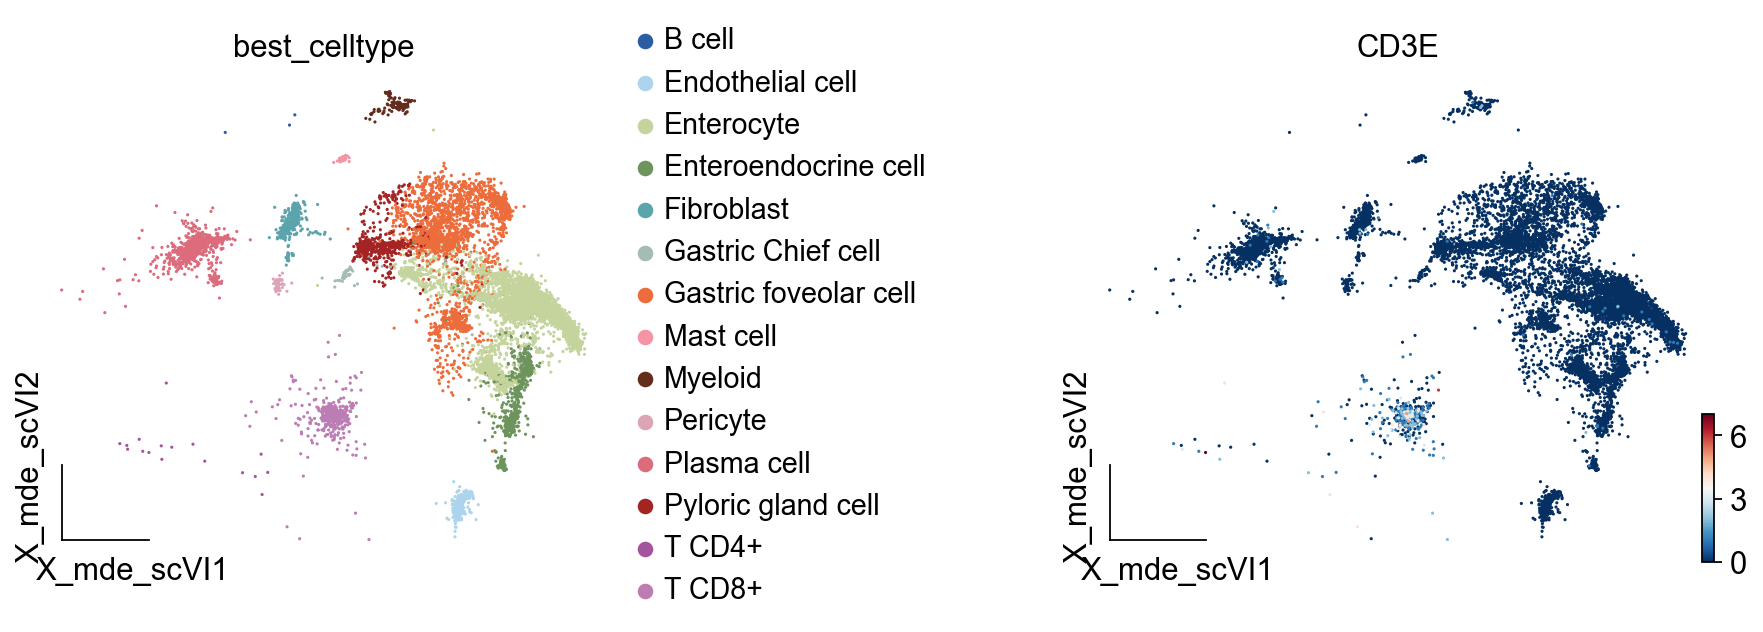

In [71]:
ov.utils.embedding(
    adata_gas,
    basis="X_mde_scVI",
    color=['best_celltype','CD3E'],
    #title='Subset',
    frameon='small',
    #ncols=1,
    wspace=0.65,
    #palette=ov.utils.pyomic_palette()[11:],
    show=False,
    #ax=ax
)

In [73]:
adata_gas.write('data/GC_RNA/GAS_VELO_ANNO.h5ad',compression='gzip')

## Map to sp

In [2]:
adata_sp=sc.read_visium('data/GC_ST/GSE245704_RAW')

reading /mnt/data/zehuazeng/result/GC_ST/HRR742264/HRR742264/outs/filtered_feature_bc_matrix.h5
 (0:00:00)


In [3]:
adata_sp

AnnData object with n_obs × n_vars = 2325 × 36601
    obs: 'in_tissue', 'array_row', 'array_col'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatial'
    obsm: 'spatial'

In [4]:
adata_sp=adata_sp[adata_sp.obs['in_tissue']==1]
adata_sp

View of AnnData object with n_obs × n_vars = 2325 × 36601
    obs: 'in_tissue', 'array_row', 'array_col'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatial'
    obsm: 'spatial'

In [5]:
adata_sp.var_names_make_unique()

In [6]:
sc.pp.calculate_qc_metrics(adata_sp, inplace=True)
adata_sp = adata_sp[:,adata_sp.var['total_counts']>100]
adata_sp=ov.pp.preprocess(adata_sp,mode='shiftlog|pearson',n_HVGs=3000,target_sum=50*1e4)
adata_sp.raw = adata_sp
adata_sp = adata_sp[:, adata_sp.var.highly_variable_features]


Begin robust gene identification
After filtration, 10851/10851 genes are kept.     Among 10851 genes, 10851 genes are robust.
End of robust gene identification.
Begin size normalization: shiftlog and HVGs selection pearson
normalizing counts per cell. The following highly-expressed genes are not considered during normalization factor computation:
['GKN1', 'LIPF', 'PGA5']
    finished (0:00:00)
extracting highly variable genes
--> added
    'highly_variable', boolean vector (adata.var)
    'highly_variable_rank', float vector (adata.var)
    'highly_variable_nbatches', int vector (adata.var)
    'highly_variable_intersection', boolean vector (adata.var)
    'means', float vector (adata.var)
    'variances', float vector (adata.var)
    'residual_variances', float vector (adata.var)
Time to analyze data in cpu: 1.2955243587493896 seconds.
End of size normalization: shiftlog and HVGs selection pearson


In [7]:
import numpy as np
cleaned_indices = ~np.isnan(adata_sp.obsm['spatial']).any(axis=1)
adata_sp=adata_sp[cleaned_indices]

In [8]:
adata_sp.obs['X'] = adata_sp.obsm['spatial'][:,0]
adata_sp.obs['Y'] = adata_sp.obsm['spatial'][:,1]

In [9]:
adata_sp.var['highly_variable']=adata_sp.var['highly_variable_features']

In [10]:
# define model
model = ov.externel.GraphST.GraphST(adata_sp, device='cuda:0')

# train model
adata_sp = model.train(n_pcs=30)

Begin to train ST data...


100%|██████████| 600/600 [00:07<00:00, 84.48it/s] 


Optimization finished for ST data!
computing PCA
    with n_comps=30
    finished (0:00:00)
GraphST embedding has been saved in adata.obsm["GraphST_embedding"]                         and adata.obsm["graphst|original|X_pca"]


In [11]:
ov.utils.cluster(adata_sp,use_rep='graphst|original|X_pca',method='mclust',n_components=10,
                 modelNames='EEV', random_state=112,
                )
adata_sp.obs['mclust_GraphST'] = ov.utils.refine_label(adata_sp, radius=20, key='mclust') 

running GaussianMixture clustering
finished: found 10 clusters and added
    'mclust', the cluster labels (adata.obs, categorical)


100%|██████████| 2325/2325 [00:00<00:00, 6963.01it/s]


In [19]:
adata_sp.write('data/GC_ST/GSE245704_RAW_mclust.h5ad',compression='gzip')

In [1]:
import scanpy as sc
import omicverse as ov

ov.plot_set()

2024-11-24 04:14:21.108119: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-11-24 04:14:21.579917: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-11-24 04:14:21.732936: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-11-24 04:14:27.030635: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT



   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

Version: 1.6.9, Tutorials: https://omicverse.readthedocs.io/
Dependency error: (pydeseq2 0.4.11 (/mnt/home/zehuazeng/software/rsc/lib/python3.10/site-packages), Requirement.parse('pydeseq2<=0.4.0,>=0.3'))


In [2]:
adata_sp=sc.read('data/GC_ST/GSE245704_RAW_mclust.h5ad',compression='gzip')

In [3]:
adata_gc1=sc.read('data/GC_RNA/GAS_VELO_ANNO.h5ad',compression='gzip')

In [4]:
#adata_sc1=adata_sc[(adata_sc.obs['Tissue']=='Para')]
import random
cellidx=random.sample(adata.obs.index.tolist(),30000)
adata_sc1=adata[cellidx]

In [5]:
adata_sc1

View of AnnData object with n_obs × n_vars = 30000 × 3000
    obs: 'patient', 'CancerType', 'CancerStage', 'nUMIs', 'mito_perc', 'detected_genes', 'cell_complexity', 'n_genes', 'doublet_score', 'predicted_doublet', 'passing_mt', 'passing_nUMIs', 'passing_ngenes', '_scvi_batch', '_scvi_labels', 'leiden', 'celltype_gbi', 'celltype_gpt', 'best_clusters', 'gpt_celltype_0', 'gpt_celltype_1', 'gpt_celltype_2', 'gpt_celltype_3', 'gpt_celltype_4', 'best_celltype', 'Major_celltype', 'Minor_celltype', 'C_scANVI', 'cell_type_from_scMulan', 'cell_type_from_mulan_smoothing', 'smoothing_score', 'cell_abbreviations', 'log2umi', 'log2counts', 'pct_counts_mt'
    var: 'mt', 'n_cells', 'percent_cells', 'robust', 'means', 'variances', 'residual_variances', 'highly_variable_rank', 'highly_variable_nbatches', 'highly_variable_intersection', 'highly_variable_features'
    uns: 'CancerStage_colors', 'CancerType_colors', 'Smoothing', 'bench_best_res', 'best_celltype_colors', 'cell_type_from_mulan_smoothing_co

In [6]:
tg=ov.space.Tangram(adata_sc1,adata_sp,clusters='best_celltype')


tangram have been install version: 1.0.4
ranking genes
    finished: added to `.uns['best_celltype_rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:00)
...Calculate The Number of Markers: 995


INFO:root:161 training genes are saved in `uns``training_genes` of both single cell and spatial Anndatas.
INFO:root:466 overlapped genes are saved in `uns``overlap_genes` of both single cell and spatial Anndatas.
INFO:root:uniform based density prior is calculated and saved in `obs``uniform_density` of the spatial Anndata.
INFO:root:rna count based density prior is calculated and saved in `obs``rna_count_based_density` of the spatial Anndata.


...Model prepared successfully


In [7]:
tg.train(mode="cells",num_epochs=500,device="cuda:0")

INFO:root:Allocate tensors for mapping.
INFO:root:Begin training with 161 genes and rna_count_based density_prior in cells mode...
INFO:root:Printing scores every 100 epochs.


Score: 0.497, KL reg: 0.193
Score: 0.821, KL reg: 0.004
Score: 0.836, KL reg: 0.003
Score: 0.838, KL reg: 0.003
Score: 0.839, KL reg: 0.003


INFO:root:Saving results..
INFO:root:spatial prediction dataframe is saved in `obsm` `tangram_ct_pred` of the spatial AnnData.


...Model train successfully


In [8]:
adata_plot=tg.cell2location()
adata_plot.obs.columns

Index(['in_tissue', 'array_row', 'array_col', 'n_genes_by_counts',
       'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts',
       'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes',
       'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'X', 'Y',
       'mclust', 'gmm_cluster', 'mclust_GraphST', 'uniform_density',
       'rna_count_based_density', 'Enteroendocrine cell', 'Pyloric gland cell',
       'Fibroblast', 'Enterocyte', 'T CD4+', 'Pericyte', 'Endothelial cell',
       'Gastric Chief cell', 'Plasma cell', 'T CD8+', 'Myeloid', 'Mast cell',
       'B cell', 'Tuft cell', 'Gastric foveolar cell'],
      dtype='object')

In [9]:
annotation_list=['Mast cell', 'B cell', 'Myeloid',
       'Plasma cell', 'Gastric foveolar cell', 'Enteroendocrine cell',
       'Pericyte', 'Enterocyte', 'Gastric Chief cell', 'Pyloric gland cell',
       'T CD4+', 'Fibroblast', 'Tuft cell', 'Endothelial cell', 'T CD8+']

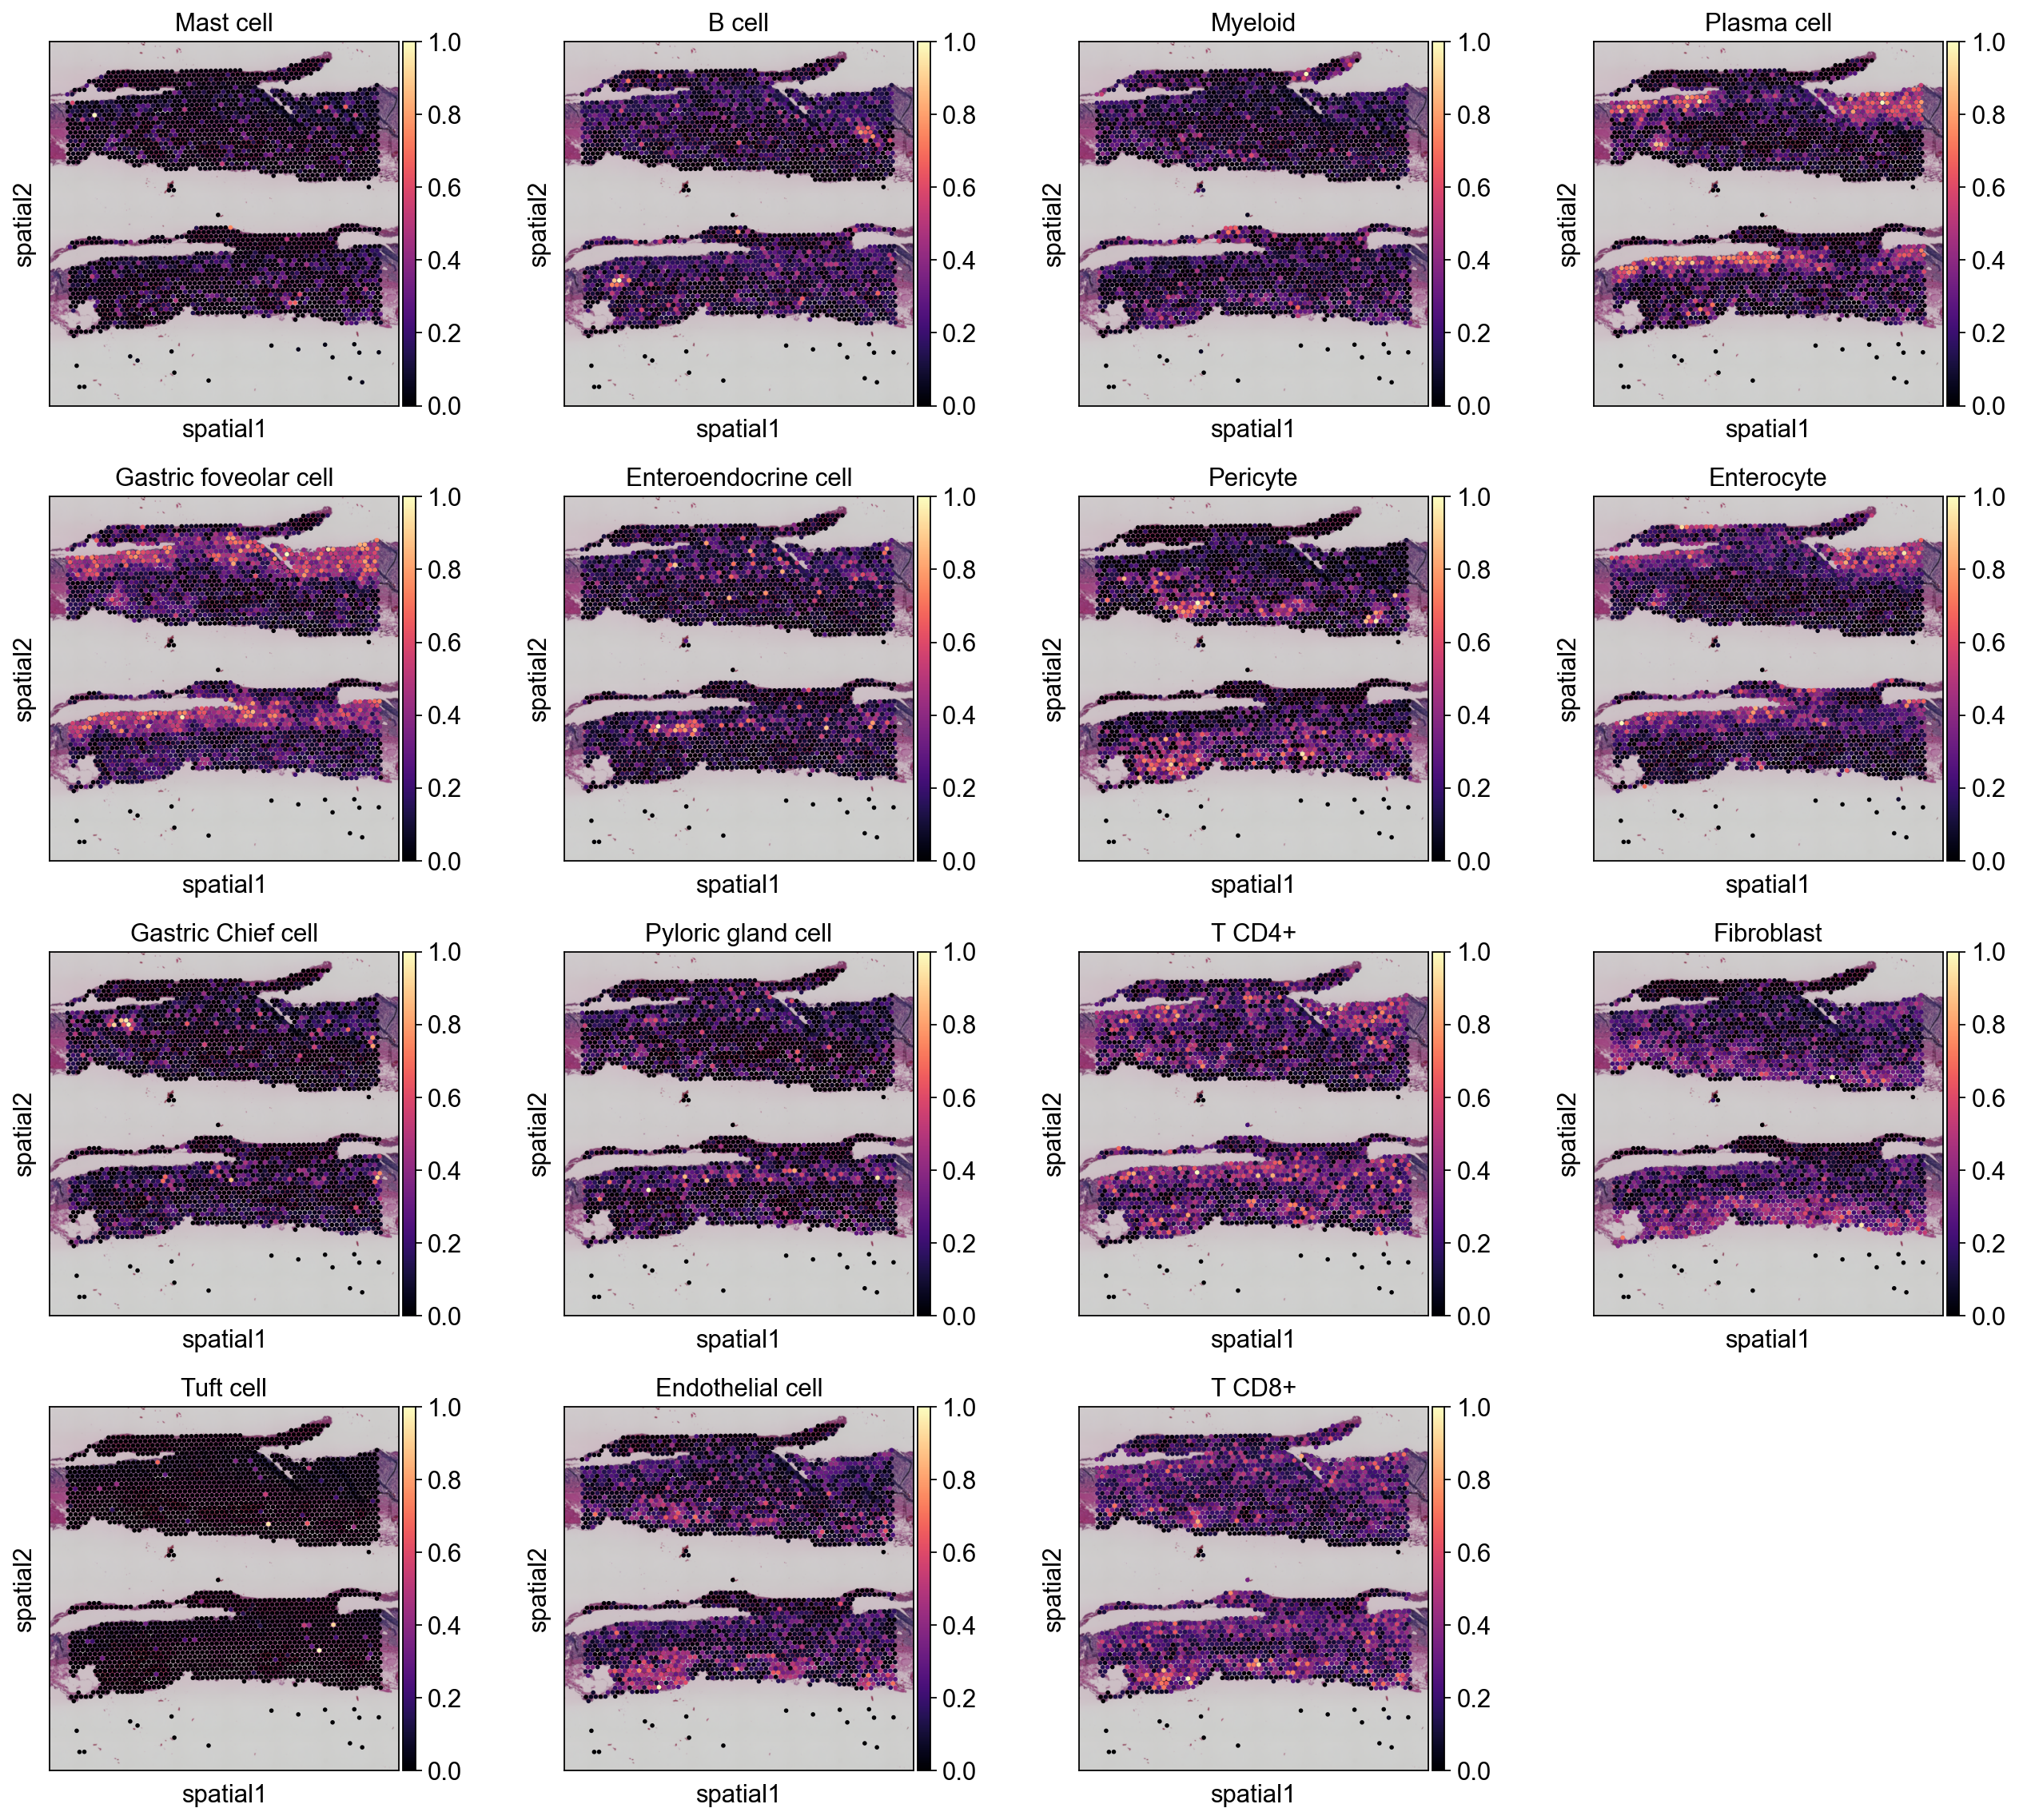

In [10]:
sc.pl.spatial(adata_plot, cmap='magma',
                  # show first 8 cell types
                  color=annotation_list,
                  ncols=4, size=1.3,
                  img_key='hires',
                  # limit color scale at 99.2% quantile of cell abundance
                  #vmin=0, vmax='p99.2'
                 )

In [11]:
adata_plot.write('data/GC_ST/GC_loc.h5ad',compression='gzip')

In [2]:
adata_plot=sc.read('data/GC_ST/GC_loc.h5ad',compression='gzip')


In [12]:
annotation_list=['Mast cell', 'B cell', 'Myeloid',
       'Plasma cell', 'Gastric foveolar cell', 'Enteroendocrine cell',
       'Pericyte', 'Enterocyte', 'Gastric Chief cell', 'Pyloric gland cell',
       'T CD4+', 'Fibroblast', 'Tuft cell', 'Endothelial cell', 'T CD8+']

## LOC pre

In [4]:
import random
adata_sc=sc.read('data/GC_RNA/GAS_VELO_ANNO.h5ad',compression='gzip')
adata_sc

AnnData object with n_obs × n_vars = 14809 × 38606
    obs: 'sample_batch', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'srr_name', 'gsm', 'patient', 'CancerType', 'mito_perc', 'cell_type_from_mulan_smoothing', 'CancerStage', 'gpt_celltype_0', 'Minor_celltype', 'cell_type_from_scMulan', 'log2umi', 'passing_ngenes', 'passing_mt', 'C_scANVI', 'gpt_celltype_2', 'best_celltype', 'cell_complexity', 'leiden', 'passing_nUMIs', 'cell_abbreviations', 'pct_counts_mt', 'detected_genes', 'smoothing_score', 'gpt_celltype_4', 'best_clusters', '_scvi_labels', 'celltype_gbi', 'n_genes', 'log2counts', 'doublet_score', 'gpt_celltype_1', 'celltype_gpt', 'Major_celltype', '_scvi_batch', 'nUMIs', 'gpt_celltype_3', 'predicted_doublet'
    var: 'gene_ids', 'feature_types', 'genome', 'Accession', 'Chromosome', 'End', 'Start', 'Strand'
    uns: 'CancerStage_colors', 'CancerType_colors', 'Smoothing', 'bench_best_res', 'best_celltype_colors', 'cell_type_from_mulan_smoothing_colors', 'cell_t

In [6]:
adata_gc=sc.read('data/GC_RNA/GC_VELO_ANNO.h5ad',compression='gzip')
adata_gc

AnnData object with n_obs × n_vars = 79036 × 38606
    obs: 'sample_batch', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'hrr_name', 'Experiment', 'title', 'BioSample', 'patient', 'CancerType', 'Stage', 'CancerStage', 'Tissue', 'cell_type_from_mulan_smoothing', 'leiden', 'predicted_doublet', 'nUMIs', 'best_clusters', 'gpt_celltype_0', 'cell_type_from_scMulan', 'celltype_gpt', 'Major_celltype', 'detected_genes', 'cell_abbreviations', 'cell_complexity', 'Minor_celltype', 'mito_perc', 'celltype_gbi', 'gpt_celltype_3', '_scvi_batch', 'smoothing_score', 'gpt_celltype_4', 'passing_ngenes', 'log2counts', 'gpt_celltype_1', 'doublet_score', 'gpt_celltype_2', 'pct_counts_mt', 'C_scANVI', 'log2umi', 'passing_nUMIs', 'n_genes', '_scvi_labels', 'passing_mt', 'best_celltype'
    var: 'gene_ids', 'feature_types', 'genome', 'Accession', 'Chromosome', 'End', 'Start', 'Strand'
    uns: 'CancerStage_colors', 'CancerType_colors', 'Smoothing', 'bench_best_res', 'best_celltype_colors', 

In [7]:
adata_sc1=sc.concat([adata_sc,adata_gc],merge='same')
adata_sc1

AnnData object with n_obs × n_vars = 93845 × 38606
    obs: 'sample_batch', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'patient', 'CancerType', 'mito_perc', 'cell_type_from_mulan_smoothing', 'CancerStage', 'gpt_celltype_0', 'Minor_celltype', 'cell_type_from_scMulan', 'log2umi', 'passing_ngenes', 'passing_mt', 'C_scANVI', 'gpt_celltype_2', 'best_celltype', 'cell_complexity', 'leiden', 'passing_nUMIs', 'cell_abbreviations', 'pct_counts_mt', 'detected_genes', 'smoothing_score', 'gpt_celltype_4', 'best_clusters', '_scvi_labels', 'celltype_gbi', 'n_genes', 'log2counts', 'doublet_score', 'gpt_celltype_1', 'celltype_gpt', 'Major_celltype', '_scvi_batch', 'nUMIs', 'gpt_celltype_3', 'predicted_doublet'
    var: 'gene_ids', 'feature_types', 'genome', 'Accession', 'Chromosome', 'End', 'Start', 'Strand'
    obsm: 'X_mde', 'X_mde_pca', 'X_mde_scANVI', 'X_mde_scVI', 'X_pca', 'X_scANVI', 'X_scMulan', 'X_scVI', 'scaled|original|X_pca'
    layers: 'ambiguous', 'matrix', 'spliced'

In [13]:
fb=ov.pl.ForbiddenCity()
color_dict={
    'B cell':fb.get_color(name='群青')['color_html'].values[0],
    'Plasma cell':fb.get_color(name='碧落')['color_html'].values[0],
    #'T cell':fb.get_color(name='麴尘')['color_html'].values[0],
    'T CD4+':fb.get_color(name='麴尘')['color_html'].values[0],
    'T CD8+':fb.get_color(name='庭芜绿')['color_html'].values[0],
    #'Natural killer cell':fb.get_color(name='缥碧')['color_html'].values[0],
    'Myeloid':fb.get_color(name='天水碧')['color_html'].values[0],
    'Mast cell':fb.get_color(name='醽醁')['color_html'].values[0],
    #'Dendritic cell':fb.get_color(name='井天')['color_html'].values[0],
    
    
    'Enterocyte':fb.get_color(name='苕荣')['color_html'].values[0],
    'Enteroendocrine cell':fb.get_color(name='杨妃')['color_html'].values[0],
    'Gastric Chief cell':fb.get_color(name='木兰')['color_html'].values[0],
    'Gastric foveolar cell':fb.get_color(name='莲红')['color_html'].values[0],
    'Pyloric gland cell':fb.get_color(name='渥赭')['color_html'].values[0],
    'Tuft cell':fb.get_color(name='唇脂')['color_html'].values[0],
    #'Mucous neck cell':fb.get_color(name='龙膏烛')['color_html'].values[0],
    'Endothelial cell':fb.get_color(name='水华朱')['color_html'].values[0],
    
    
    'Fibroblast':fb.get_color(name='紫蒲')['color_html'].values[0],
    'Pericyte':fb.get_color(name='木槿')['color_html'].values[0],

    'Unknown':fb.get_color(name='育阳染')['color_html'].values[0],
}

<AxesSubplot: title={'center': 'best_celltype'}, xlabel='X_mde_scVI1', ylabel='X_mde_scVI2'>

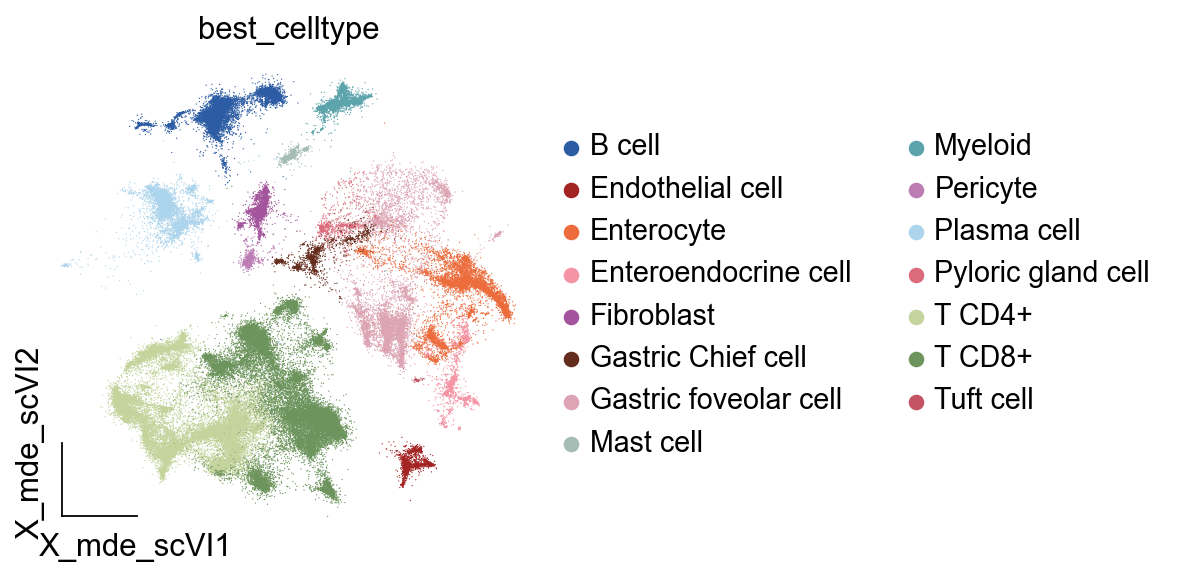

In [14]:
ov.utils.embedding(
    adata_sc1,
    basis="X_mde_scVI",
    color=['best_celltype'],
    #title='Subset',
    frameon='small',
    #ncols=1,
    wspace=0.65,
    palette=color_dict,
    show=False,
    #ax=ax
)

In [9]:
adata_sc1.obs['CancerStage'].unique()

['No', 'T1', 'T3', 'T4', 'T2']
Categories (5, object): ['No', 'T1', 'T2', 'T3', 'T4']

In [22]:
adata_sc1.write('data/GC_ST/GAS_GC_RAW_velo.h5ad')

In [13]:
adata_sc1=sc.read('data/GC_ST/GAS_GC_RAW_velo.h5ad')

In [15]:
adata_sp=sc.read('data/GC_ST/GSE245704_RAW_mclust.h5ad',compression='gzip')
adata_sp

AnnData object with n_obs × n_vars = 2560 × 3000
    obs: 'in_tissue', 'array_row', 'array_col', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'X', 'Y', 'mclust', 'gmm_cluster', 'mclust_GraphST'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'percent_cells', 'robust', 'means', 'variances', 'residual_variances', 'highly_variable_rank', 'highly_variable_features', 'highly_variable'
    uns: 'hvg', 'log1p', 'mclust_GraphST_colors', 'spatial'
    obsm: 'GraphST_embedding', 'adj', 'distance_matrix', 'emb', 'feat', 'feat_a', 'graph_neigh', 'graphst|original|X_pca', 'label_CSL', 'spatial'
    layers: 'counts'

In [16]:
adata_sp.X.max()

12.65857

## GAS

In [17]:
adata_sc=adata_sc1[adata_sc1.obs['CancerStage'].isin(['No'])]
adata_sc

View of AnnData object with n_obs × n_vars = 12676 × 38606
    obs: 'sample_batch', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'patient', 'CancerType', 'mito_perc', 'cell_type_from_mulan_smoothing', 'CancerStage', 'gpt_celltype_0', 'Minor_celltype', 'cell_type_from_scMulan', 'log2umi', 'passing_ngenes', 'passing_mt', 'C_scANVI', 'gpt_celltype_2', 'best_celltype', 'cell_complexity', 'leiden', 'passing_nUMIs', 'cell_abbreviations', 'pct_counts_mt', 'detected_genes', 'smoothing_score', 'gpt_celltype_4', 'best_clusters', '_scvi_labels', 'celltype_gbi', 'n_genes', 'log2counts', 'doublet_score', 'gpt_celltype_1', 'celltype_gpt', 'Major_celltype', '_scvi_batch', 'nUMIs', 'gpt_celltype_3', 'predicted_doublet'
    var: 'gene_ids', 'feature_types', 'genome', 'Accession', 'Chromosome', 'End', 'Start', 'Strand'
    uns: 'best_celltype_colors'
    obsm: 'X_mde', 'X_mde_pca', 'X_mde_scANVI', 'X_mde_scVI', 'X_pca', 'X_scANVI', 'X_scMulan', 'X_scVI', 'scaled|original|X_pca'
    

<AxesSubplot: title={'center': 'best_celltype'}, xlabel='X_mde_scVI1', ylabel='X_mde_scVI2'>

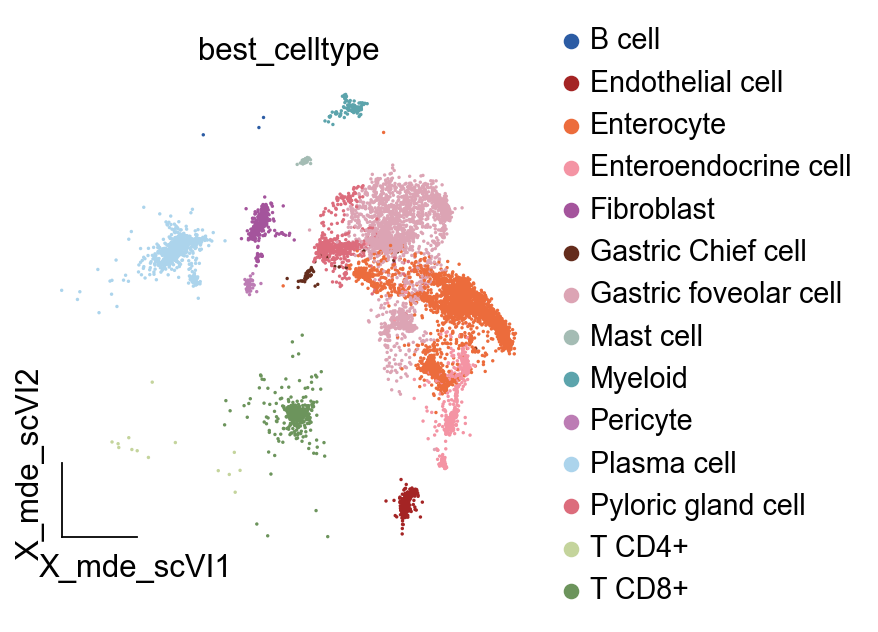

In [18]:
ov.utils.embedding(
    adata_sc,
    basis="X_mde_scVI",
    color=['best_celltype'],
    #title='Subset',
    frameon='small',
    #ncols=1,
    wspace=0.65,
    #palette=ov.utils.pyomic_palette()[11:],
    show=False,
    #ax=ax
)

In [19]:
adata_sc.X.max()

24749.0

In [20]:
adata_sc=ov.pp.preprocess(adata_sc,mode='shiftlog|pearson',n_HVGs=3000,)
adata_sc.raw=adata_sc
adata_sc=adata_sc[:,adata_sc.var.highly_variable_features]
adata_sc

Begin robust gene identification
After filtration, 30807/38606 genes are kept.     Among 30807 genes, 23835 genes are robust.
End of robust gene identification.
Begin size normalization: shiftlog and HVGs selection pearson
normalizing counts per cell. The following highly-expressed genes are not considered during normalization factor computation:
['GKN1', 'IGKC', 'SST', 'JCHAIN', 'MLN', 'PGC', 'DEFA6', 'DEFA5', 'LIPF', 'HBB', 'MALAT1', 'IGHA2', 'IGHG4', 'IGHA1', 'IGHG1', 'IGHG3', 'IGHM', 'GAST', 'GIP', 'TFF1', 'IGLL5', 'IGLC2', 'IGLC3', 'IGLC7']
    finished (0:00:00)
extracting highly variable genes
--> added
    'highly_variable', boolean vector (adata.var)
    'highly_variable_rank', float vector (adata.var)
    'highly_variable_nbatches', int vector (adata.var)
    'highly_variable_intersection', boolean vector (adata.var)
    'means', float vector (adata.var)
    'variances', float vector (adata.var)
    'residual_variances', float vector (adata.var)
Time to analyze data in cpu: 4

View of AnnData object with n_obs × n_vars = 12676 × 3000
    obs: 'sample_batch', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'patient', 'CancerType', 'mito_perc', 'cell_type_from_mulan_smoothing', 'CancerStage', 'gpt_celltype_0', 'Minor_celltype', 'cell_type_from_scMulan', 'log2umi', 'passing_ngenes', 'passing_mt', 'C_scANVI', 'gpt_celltype_2', 'best_celltype', 'cell_complexity', 'leiden', 'passing_nUMIs', 'cell_abbreviations', 'pct_counts_mt', 'detected_genes', 'smoothing_score', 'gpt_celltype_4', 'best_clusters', '_scvi_labels', 'celltype_gbi', 'n_genes', 'log2counts', 'doublet_score', 'gpt_celltype_1', 'celltype_gpt', 'Major_celltype', '_scvi_batch', 'nUMIs', 'gpt_celltype_3', 'predicted_doublet'
    var: 'gene_ids', 'feature_types', 'genome', 'Accession', 'Chromosome', 'End', 'Start', 'Strand', 'n_cells', 'percent_cells', 'robust', 'means', 'variances', 'residual_variances', 'highly_variable_rank', 'highly_variable_features'
    uns: 'best_celltype_colors', 

In [21]:
adata_sp,adata_sc

(AnnData object with n_obs × n_vars = 2560 × 3000
     obs: 'in_tissue', 'array_row', 'array_col', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'X', 'Y', 'mclust', 'gmm_cluster', 'mclust_GraphST'
     var: 'gene_ids', 'feature_types', 'genome', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'percent_cells', 'robust', 'means', 'variances', 'residual_variances', 'highly_variable_rank', 'highly_variable_features', 'highly_variable'
     uns: 'hvg', 'log1p', 'mclust_GraphST_colors', 'spatial'
     obsm: 'GraphST_embedding', 'adj', 'distance_matrix', 'emb', 'feat', 'feat_a', 'graph_neigh', 'graphst|original|X_pca', 'label_CSL', 'spatial'
     layers: 'counts',
 View of AnnData object with n_obs × n_vars = 12676 × 3000
     obs: 'sample_batch', 'in

In [22]:
cellmap=ov.space.CellLoc(adata_sc,adata_sp,use_rep_sc='X_scVI',
                    use_rep_sp='graphst|original|X_pca',)

In [23]:
map_pd=cellmap.loc_map(sc_type='best_celltype',sp_type='mclust',
            alpha=0.1,aware_power = 2,verbose=True,
            aware_spatial = True,aware_multi=True,use_gpu=True)

Calculating dissimilarity using euclidean distance on scaled data...
normalizing counts per cell
    finished (0:00:00)
... as `zero_center=True`, sparse input is densified and may lead to large memory consumption
Constructing connectivity...
k = 10
aware_spatial = True
aware_multi = True
aware power = 2
Running OT...
alpha = 0.1
It.  |Loss        |Relative loss|Absolute loss
------------------------------------------------
    0|5.022481e-01|0.000000e+00|0.000000e+00
    1|4.636880e-01|8.315964e-02|3.856013e-02
    2|4.631040e-01|1.261137e-03|5.840374e-04
    3|4.624333e-01|1.450360e-03|6.706947e-04
    4|4.616765e-01|1.639286e-03|7.568196e-04
    5|4.615355e-01|3.054719e-04|1.409861e-04
    6|4.615254e-01|2.185037e-05|1.008450e-05
    7|4.615241e-01|2.762662e-06|1.275035e-06
    8|4.615239e-01|3.459261e-07|1.596532e-07
    9|4.615239e-01|1.185929e-07|5.473344e-08
   10|4.615239e-01|6.494020e-08|2.997145e-08
   11|4.615239e-01|2.715877e-08|1.253442e-08
   12|4.615238e-01|7.039190e-09|

In [24]:
cellmap.loc_prob(spot_cell_prob=adata_plot.obs[annotation_list],
                 sc_type='best_celltype',sc_prop=0.5,
                 n_cpu=8)


100%|██████████| 2560/2560 [00:00<00:00, 3540.03it/s]


INFO: Pandarallel will run on 8 workers.
INFO: Pandarallel will use Memory file system to transfer data between the main process and workers.


In [25]:
adata_sc_copy=cellmap.loc_assign(random = True,top_num = 5)
adata_sc_copy.write('data/GC_ST/GC_GAS_mapping.h5ad',compression='gzip')

Assigning spatial coordinates to cells...
random = True
Maximum number of cells assigned to spots: 5
normalizing counts per cell
    finished (0:00:00)
normalizing counts per cell
    finished (0:00:00)
Assignment done!
...assigning spatial coordinates to single cell data
...adding spatial coordinates to single cell data


[<AxesSubplot: title={'center': 'best_celltype'}, xlabel='spatial1', ylabel='spatial2'>]

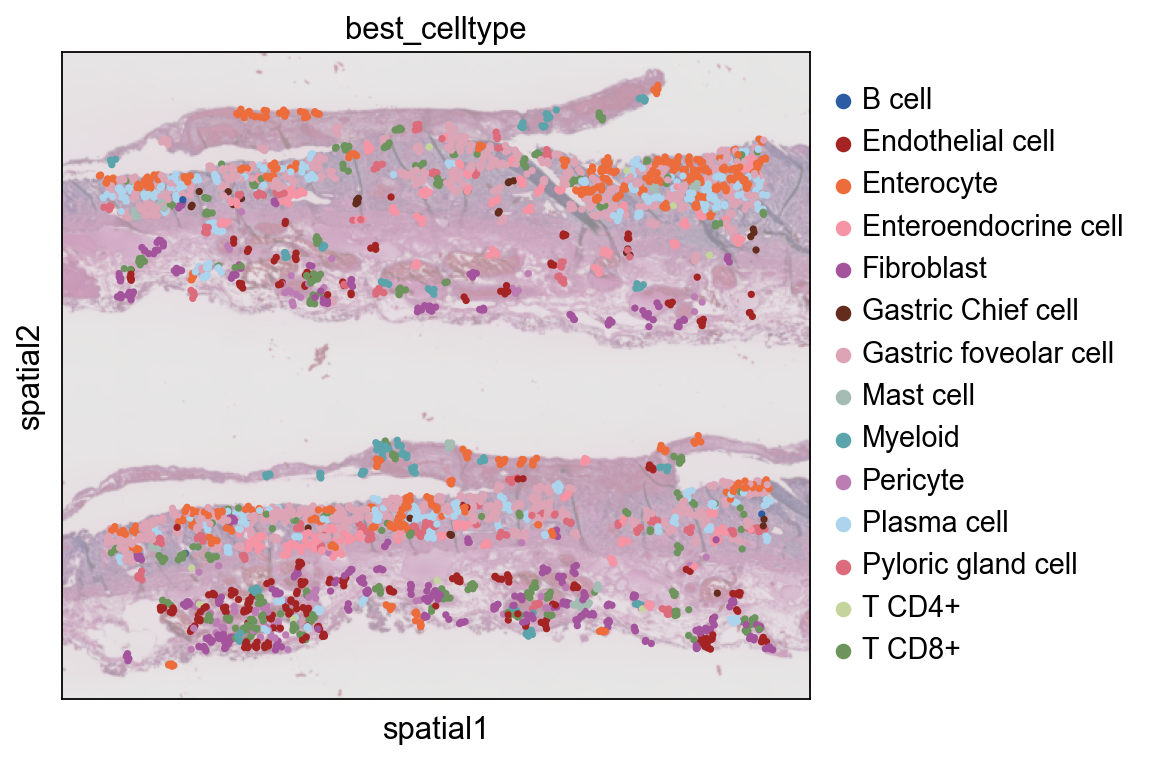

In [26]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(6,6))
sc.pl.spatial(adata_sc_copy, cmap='magma',
                  # show first 8 cell types
                  color='best_celltype',
                  ncols=4, size=1,
                  img_key='hires',
                  alpha_img=0.5,
              ax=ax,show=False
                  # limit color scale at 99.2% quantile of cell abundance
                  #vmin=0, vmax='p99.2'
                 )

## T1

In [27]:
adata_sc=adata_sc1[adata_sc1.obs['CancerStage'].isin(['T1'])]
adata_sc

View of AnnData object with n_obs × n_vars = 9681 × 38606
    obs: 'sample_batch', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'patient', 'CancerType', 'mito_perc', 'cell_type_from_mulan_smoothing', 'CancerStage', 'gpt_celltype_0', 'Minor_celltype', 'cell_type_from_scMulan', 'log2umi', 'passing_ngenes', 'passing_mt', 'C_scANVI', 'gpt_celltype_2', 'best_celltype', 'cell_complexity', 'leiden', 'passing_nUMIs', 'cell_abbreviations', 'pct_counts_mt', 'detected_genes', 'smoothing_score', 'gpt_celltype_4', 'best_clusters', '_scvi_labels', 'celltype_gbi', 'n_genes', 'log2counts', 'doublet_score', 'gpt_celltype_1', 'celltype_gpt', 'Major_celltype', '_scvi_batch', 'nUMIs', 'gpt_celltype_3', 'predicted_doublet'
    var: 'gene_ids', 'feature_types', 'genome', 'Accession', 'Chromosome', 'End', 'Start', 'Strand'
    uns: 'best_celltype_colors'
    obsm: 'X_mde', 'X_mde_pca', 'X_mde_scANVI', 'X_mde_scVI', 'X_pca', 'X_scANVI', 'X_scMulan', 'X_scVI', 'scaled|original|X_pca'
    l

<AxesSubplot: title={'center': 'best_celltype'}, xlabel='X_mde_scVI1', ylabel='X_mde_scVI2'>

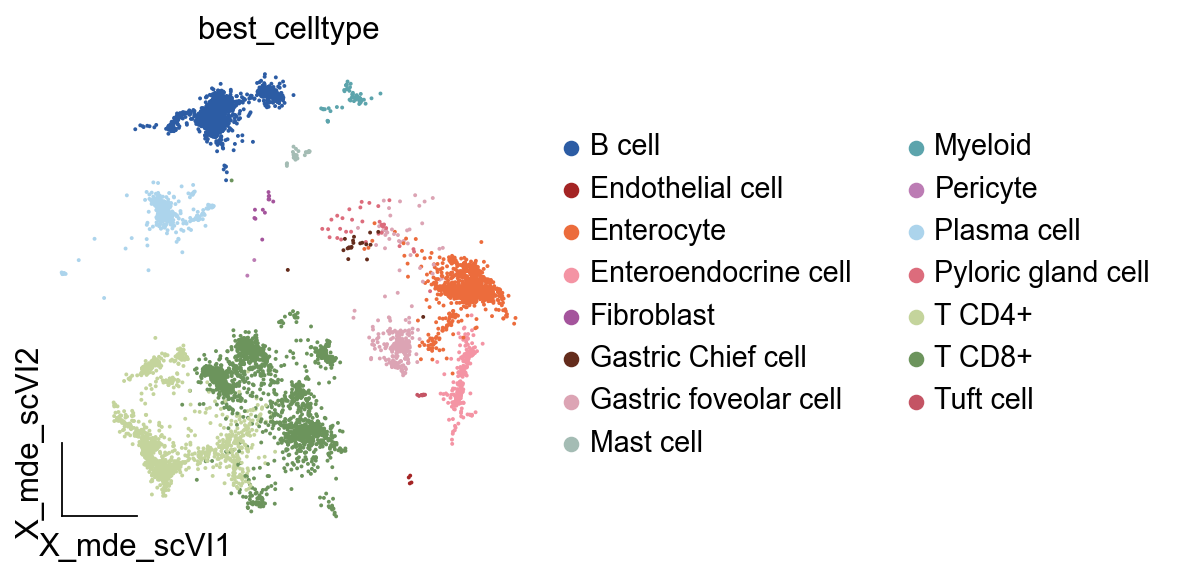

In [28]:
ov.utils.embedding(
    adata_sc,
    basis="X_mde_scVI",
    color=['best_celltype'],
    #title='Subset',
    frameon='small',
    #ncols=1,
    wspace=0.65,
    #palette=ov.utils.pyomic_palette()[11:],
    show=False,
    #ax=ax
)

In [29]:
adata_sc.X.max()

22984.0

In [30]:
adata_sc=ov.pp.preprocess(adata_sc,mode='shiftlog|pearson',n_HVGs=3000,)
adata_sc.raw=adata_sc
adata_sc=adata_sc[:,adata_sc.var.highly_variable_features]
adata_sc

Begin robust gene identification
After filtration, 29612/38606 genes are kept.     Among 29612 genes, 23606 genes are robust.
End of robust gene identification.
Begin size normalization: shiftlog and HVGs selection pearson
normalizing counts per cell. The following highly-expressed genes are not considered during normalization factor computation:
['IGKC', 'IGKV4-1', 'IGKV1-5', 'IGKV1-9', 'IGKV3-11', 'IGKV1-12', 'IGKV3-15', 'IGKV1-16', 'IGKV1-17', 'IGKV3-20', 'IGKV6-21', 'IGKV2-24', 'IGKV1-27', 'IGKV2-28', 'IGKV2-29', 'IGKV2-30', 'IGKV1D-39', 'IGKV1D-33', 'IGKV2D-28', 'IGKV2D-24', 'IGKV6D-21', 'IGKV3D-20', 'IGKV3D-15', 'SST', 'JCHAIN', 'PGC', 'HBB', 'PGA3', 'IGHA1', 'IGHG1', 'IGHV6-1', 'IGHV1-2', 'IGHV7-4-1', 'IGHV2-5', 'IGHV3-7', 'IGHV1-18', 'IGHV3-21', 'IGHV3-23', 'IGHV1-24', 'IGHV2-26', 'IGHV3-30', 'IGHV4-34', 'IGHV4-39', 'IGHV1-46', 'IGHV3-48', 'IGHV3-49', 'IGHV5-51', 'IGHV1-58', 'IGHV4-59', 'IGHV1-69D', 'IGHV3-73', 'IGHV3-74', 'GAST', 'ENSG00000280441', 'IGLV4-69', 'IGLV8-61', 'IGL

View of AnnData object with n_obs × n_vars = 9681 × 3000
    obs: 'sample_batch', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'patient', 'CancerType', 'mito_perc', 'cell_type_from_mulan_smoothing', 'CancerStage', 'gpt_celltype_0', 'Minor_celltype', 'cell_type_from_scMulan', 'log2umi', 'passing_ngenes', 'passing_mt', 'C_scANVI', 'gpt_celltype_2', 'best_celltype', 'cell_complexity', 'leiden', 'passing_nUMIs', 'cell_abbreviations', 'pct_counts_mt', 'detected_genes', 'smoothing_score', 'gpt_celltype_4', 'best_clusters', '_scvi_labels', 'celltype_gbi', 'n_genes', 'log2counts', 'doublet_score', 'gpt_celltype_1', 'celltype_gpt', 'Major_celltype', '_scvi_batch', 'nUMIs', 'gpt_celltype_3', 'predicted_doublet'
    var: 'gene_ids', 'feature_types', 'genome', 'Accession', 'Chromosome', 'End', 'Start', 'Strand', 'n_cells', 'percent_cells', 'robust', 'means', 'variances', 'residual_variances', 'highly_variable_rank', 'highly_variable_features'
    uns: 'best_celltype_colors', '

In [31]:
adata_sp,adata_sc

(AnnData object with n_obs × n_vars = 2560 × 3000
     obs: 'in_tissue', 'array_row', 'array_col', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'X', 'Y', 'mclust', 'gmm_cluster', 'mclust_GraphST', 'type'
     var: 'gene_ids', 'feature_types', 'genome', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'percent_cells', 'robust', 'means', 'variances', 'residual_variances', 'highly_variable_rank', 'highly_variable_features', 'highly_variable'
     uns: 'hvg', 'log1p', 'mclust_GraphST_colors', 'spatial'
     obsm: 'GraphST_embedding', 'adj', 'distance_matrix', 'emb', 'feat', 'feat_a', 'graph_neigh', 'graphst|original|X_pca', 'label_CSL', 'spatial'
     layers: 'counts',
 View of AnnData object with n_obs × n_vars = 9681 × 3000
     obs: 'sample_batc

In [32]:
cellmap=ov.space.CellLoc(adata_sc,adata_sp,use_rep_sc='X_scVI',
                    use_rep_sp='graphst|original|X_pca',)

In [33]:
map_pd=cellmap.loc_map(sc_type='best_celltype',sp_type='mclust',
            alpha=0.1,aware_power = 2,verbose=True,
            aware_spatial = True,aware_multi=True,use_gpu=True)

Calculating dissimilarity using euclidean distance on scaled data...
normalizing counts per cell
    finished (0:00:00)
... as `zero_center=True`, sparse input is densified and may lead to large memory consumption
Constructing connectivity...
k = 10
aware_spatial = True
aware_multi = True
aware power = 2
Running OT...
alpha = 0.1
It.  |Loss        |Relative loss|Absolute loss
------------------------------------------------
    0|5.037347e-01|0.000000e+00|0.000000e+00
    1|4.597802e-01|9.559903e-02|4.395454e-02
    2|4.592998e-01|1.045950e-03|4.804045e-04
    3|4.592220e-01|1.693065e-04|7.774927e-05
    4|4.589848e-01|5.168326e-04|2.372183e-04
    5|4.585958e-01|8.481117e-04|3.889405e-04
    6|4.583007e-01|6.440886e-04|2.951862e-04
    7|4.581359e-01|3.596227e-04|1.647561e-04
    8|4.580816e-01|1.185777e-04|5.431827e-05
    9|4.580683e-01|2.909851e-05|1.332910e-05
   10|4.580641e-01|8.972200e-06|4.109843e-06
   11|4.580616e-01|5.614681e-06|2.571869e-06
   12|4.580598e-01|3.874584e-06|

In [34]:
cellmap.loc_prob(spot_cell_prob=adata_plot.obs[annotation_list],
                 sc_type='best_celltype',sc_prop=0.5,
                 n_cpu=8)


100%|██████████| 2560/2560 [00:00<00:00, 3346.37it/s]


INFO: Pandarallel will run on 8 workers.
INFO: Pandarallel will use Memory file system to transfer data between the main process and workers.


In [35]:
adata_sc_copy=cellmap.loc_assign(random = True,top_num = 5)
adata_sc_copy.write('data/GC_ST/GC_T1_mapping.h5ad',compression='gzip')

Assigning spatial coordinates to cells...
random = True
Maximum number of cells assigned to spots: 5
normalizing counts per cell
    finished (0:00:00)
normalizing counts per cell
    finished (0:00:00)
Assignment done!
...assigning spatial coordinates to single cell data
...adding spatial coordinates to single cell data


In [36]:
adata_sc_copy.obs

,sample_batch,initial_size_unspliced,initial_size_spliced,initial_size,patient,CancerType,mito_perc,cell_type_from_mulan_smoothing,CancerStage,gpt_celltype_0,...,_scvi_batch,nUMIs,gpt_celltype_3,predicted_doublet,type,Cell_xcoord,Cell_ycoord,spot_type,spot,spot_value
EGC:GTGTTAGTCTTCCTTC-14,CTTC-1,1471,10746,10746.0,EGC,Mixed,0.046532,Cholangiocyte,T1,Epithelial cells,...,18,14549.0,Epithelial cells,False,Enterocyte,28190.28,9458.86,9,AACAGGCCAACGATTA-1,1.032951e-04
EGC:CACAAACTCTTTACAC-14,ACAC-1,3769,20717,20717.0,EGC,Mixed,0.153750,Cholangiocyte,T1,Epithelial cells,...,18,31987.0,Epithelial cells,False,Enterocyte,28102.15,9533.85,9,AACAGGCCAACGATTA-1,1.032951e-04
EGC:ATTACTCAGCCAGTAG-14,GTAG-1,1554,8355,8355.0,EGC,Mixed,0.124412,Cholangiocyte,T1,Epithelial cells,...,18,12338.0,Epithelial cells,False,Enterocyte,28114.14,9514.23,9,AACAGGCCAACGATTA-1,1.032951e-04
EGC:CGGACGTGTTTACTCT-14,CTCT-1,1613,10133,10133.0,EGC,Mixed,0.166763,Cholangiocyte,T1,Gastric foveolar cells,...,18,15651.0,- Surface mucous cells,False,Gastric foveolar cell,28136.49,9468.42,9,AACAGGCCAACGATTA-1,4.034965e-142
HRR207233:TCACAAGAGCTAGTGG-1,GTGG-1,1102,941,941.0,GC05,Mixed,0.108478,Cholangiocyte,T1,Epithelial cells,...,23,2996.0,Epithelial cells,False,Gastric foveolar cell,28144.71,9516.37,9,AACAGGCCAACGATTA-1,4.034965e-142
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
EGC:TATCAGGCACGGACAA-14,ACAA-1,289,505,505.0,EGC,Mixed,0.038896,Memory CD8 T cell,T1,Effector T cells,...,18,797.0,- Cytotoxic T cells,False,T CD8+,21066.17,10416.33,4,TGTTCAGCGAGGCAGT-1,4.034965e-142
HRR207233:AGAGCTTCAAAGCGGT-1,CGGT-1,380,1424,1424.0,GC05,Mixed,0.065046,NK cell,T1,Cytotoxic T cells,...,23,3167.0,- Natural killer cells,False,T CD8+,21156.94,10386.65,4,TGTTCAGCGAGGCAGT-1,4.034965e-142
HRR207232:ACGATGTTCATCGATG-1,GATG-1,610,1626,1626.0,GC05,Mixed,0.051490,Memory CD8 T cell,T1,Cytotoxic T cells,...,23,3457.0,- Cytotoxic T cells,False,T CD8+,21150.66,10386.75,4,TGTTCAGCGAGGCAGT-1,4.034965e-142
HRR207232:GTCGTAAGTGTGGTTT-1,GTTT-1,342,900,900.0,GC05,Mixed,0.069425,CD8 T cell,T1,Cytotoxic T cells,...,23,2103.0,- Cytotoxic T cells,False,T CD8+,21128.97,10416.32,4,TGTTCAGCGAGGCAGT-1,4.034965e-142


[<AxesSubplot: title={'center': 'best_celltype'}, xlabel='spatial1', ylabel='spatial2'>]

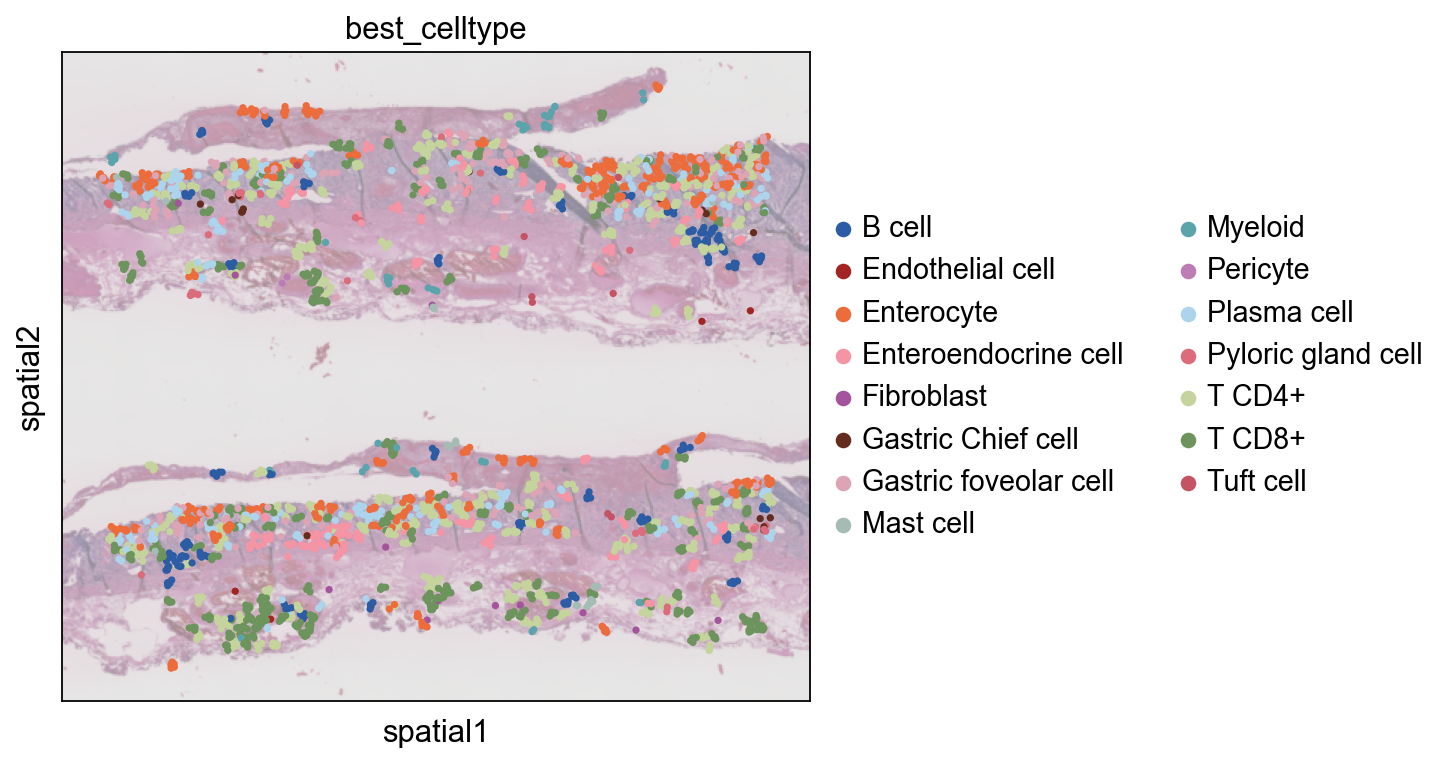

In [37]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(6,6))
sc.pl.spatial(adata_sc_copy, cmap='magma',
                  # show first 8 cell types
                  color='best_celltype',
                  ncols=4, size=1,
                  img_key='hires',
                  alpha_img=0.5,
              ax=ax,show=False
                  # limit color scale at 99.2% quantile of cell abundance
                  #vmin=0, vmax='p99.2'
                 )

## Visual

In [38]:
adata_sp_obs=ov.read('data/GC_ST/GC_ST_anno_obs.csv',index_col=0)
adata_sp_obs.head()

,in_tissue,array_row,array_col,mclust,Layer
gc:AACAGGCCAACGATTA-1,1,71,127,c1,Foveolar Layer
gc:AACAGGTTATTGCACC-1,1,28,86,c2,Neck Layer
gc:AACAGTCAGGCTCCGC-1,1,24,6,c5,Chief Layer
gc:AACATAGTCTATCTAC-1,1,58,26,c10,Fibro Layer
gc:AACATCTAATGACCGG-1,1,67,55,c4,Tumor


In [39]:
adata_sc_copy=sc.read('data/GC_ST/GC_T1_mapping.h5ad',compression='gzip')

In [40]:
adata_sp_obs_layer_dict=dict(zip(
    [i.split(':')[1] for i in adata_sp_obs.index.tolist()],
    adata_sp_obs['Layer'].tolist()
))

In [41]:
adata_sc_copy.obs['Layer']=adata_sc_copy.obs['spot'].map(adata_sp_obs_layer_dict)

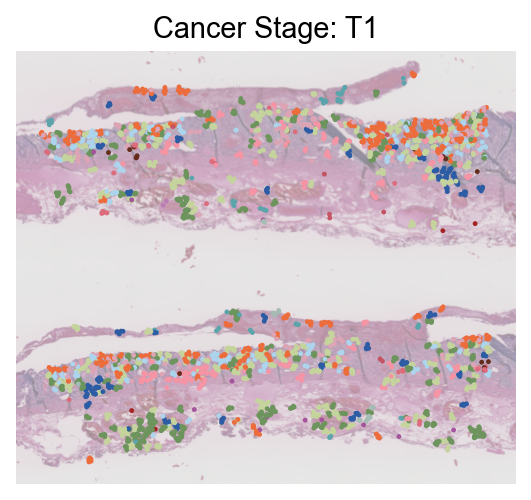

In [42]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(4,4))
sc.pl.spatial(adata_sc_copy, cmap='magma',
                  # show first 8 cell types
                  color='best_celltype',
                  ncols=4, size=1,
                  img_key='hires',
                  alpha_img=0.5,
                  ax=ax,show=False,
                  frameon=False,
              legend_loc=None,
                  # limit color scale at 99.2% quantile of cell abundance
                  #vmin=0, vmax='p99.2'
                 )
#ax.legend(bbox_to_anchor=(1.05,0),ncols=2,fontsize=12)
ax.set_title('Cancer Stage: T1',fontsize=13)
fig.savefig('figures/st/spatail-gc-t1-loc-44.png',dpi=300,bbox_inches='tight')

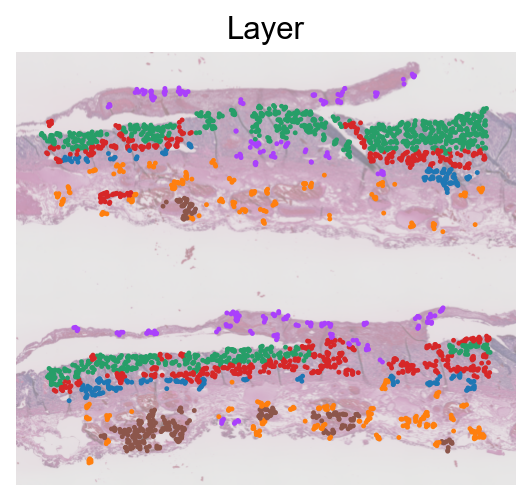

In [43]:
sc.pl.spatial(adata_sc_copy, cmap='magma',
                  # show first 8 cell types
                  color='Layer',
                  ncols=4, size=1,
                  img_key='hires',
                  alpha_img=0.5,
                  #ax=ax,show=False,
                  frameon=False,
              legend_loc=None,
                  # limit color scale at 99.2% quantile of cell abundance
                  #vmin=0, vmax='p99.2'
                 )

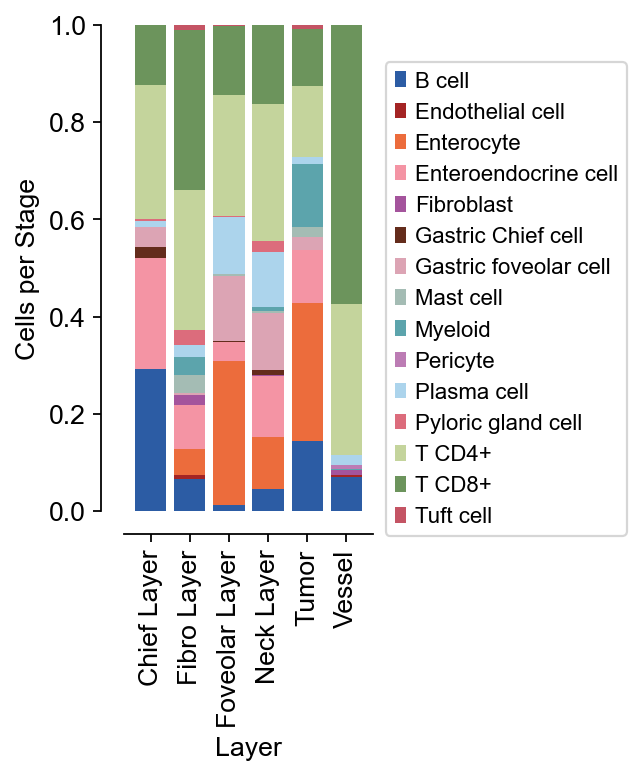

In [44]:
import matplotlib.pyplot as plt
fig,ax=plt.subplots(figsize = (2,4))
ov.pl.cellproportion(adata=adata_sc_copy,celltype_clusters='best_celltype',
                    groupby='Layer',legend=True,ax=ax)
plt.xticks(fontsize=12,rotation=90)
plt.yticks(fontsize=12)
fig.savefig('figures/st/prop-gc-t1-loc-44.png',dpi=300,bbox_inches='tight')

In [45]:
adata_sc_copy=sc.read('data/GC_ST/GC_GAS_mapping.h5ad',compression='gzip')

In [46]:
adata_sp_obs_layer_dict=dict(zip(
    [i.split(':')[1] for i in adata_sp_obs.index.tolist()],
    adata_sp_obs['Layer'].tolist()
))

In [47]:
adata_sc_copy.obs['Layer']=adata_sc_copy.obs['spot'].map(adata_sp_obs_layer_dict)

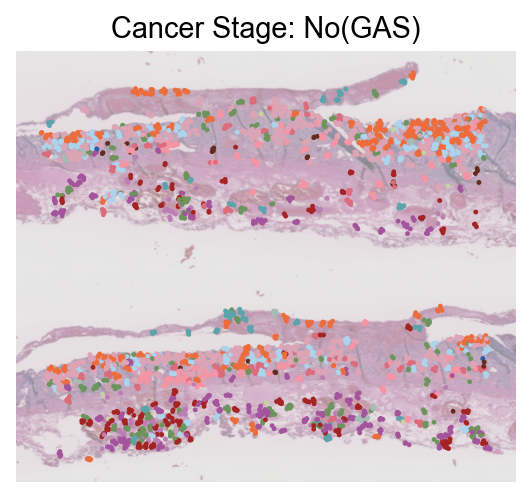

In [48]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(4,4))
sc.pl.spatial(adata_sc_copy, cmap='magma',
                  # show first 8 cell types
                  color='best_celltype',
                  ncols=4, size=1,
                  img_key='hires',
                  alpha_img=0.5,
                  ax=ax,show=False,
                  frameon=False,
              legend_loc=None,
                  # limit color scale at 99.2% quantile of cell abundance
                  #vmin=0, vmax='p99.2'
                 )
#ax.legend(bbox_to_anchor=(1.05,0),ncols=2,fontsize=12)
ax.set_title('Cancer Stage: No(GAS)',fontsize=13)
fig.savefig('figures/st/spatail-gc-no-loc-44.png',dpi=300,bbox_inches='tight')

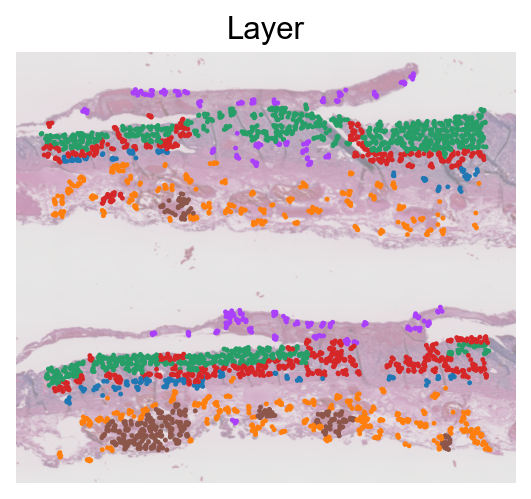

In [49]:
sc.pl.spatial(adata_sc_copy, cmap='magma',
                  # show first 8 cell types
                  color='Layer',
                  ncols=4, size=1,
                  img_key='hires',
                  alpha_img=0.5,
                  #ax=ax,show=False,
                  frameon=False,
              legend_loc=None,
                  # limit color scale at 99.2% quantile of cell abundance
                  #vmin=0, vmax='p99.2'
                 )

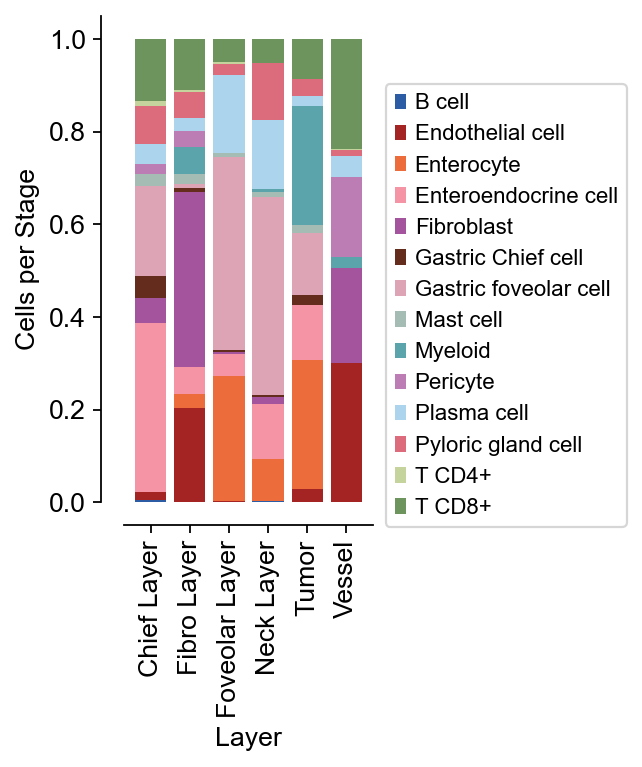

In [51]:
import matplotlib.pyplot as plt
fig,ax=plt.subplots(figsize = (2,4))
ov.pl.cellproportion(adata=adata_sc_copy,celltype_clusters='best_celltype',
                    groupby='Layer',legend=True,ax=ax)
plt.xticks(fontsize=12,rotation=90)
plt.yticks(fontsize=12)
fig.savefig('figures/st/prop-gc-no-loc-44.png',dpi=300,bbox_inches='tight')